# Análisis Exploratorio de Datos

Notebook de la etapa **2** del pipeline de detección de cyberbullying en texto. Su rol es servir de **eslabón** entre la extracción de características (01) y el modelado (03): aquí se describe la estructura del dataset preprocesado y se evidencian propiedades relevantes (desbalance de clases, textos duplicados, longitud de los mensajes y vocabulario típico de cada clase). La partición entrenamiento/test se define en la etapa de modelado (03) con la misma configuración en todo el pipeline. Este análisis alimenta la sección metodológica de la tesis.

> El dataset de entrada es `../data/processed/cyberbullying_preprocessed.csv`, generado por la etapa 00 (columnas `text`, `label`, `text_preprocessed`).


## Carga del dataset

Se carga el dataset intermedio generado por la etapa 00 (`../data/processed/cyberbullying_preprocessed.csv`, columnas `text`, `label`, `text_preprocessed`). `%matplotlib inline` habilita la renderización de las figuras dentro del notebook.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

df = pd.read_csv('../data/processed/cyberbullying_preprocessed.csv')

## Estructura y calidad del dataset

Antes de cualquier análisis se verifica la calidad de los datos: forma (dimensiones), tipos por columna, presencia de textos vacíos tras el preprocesado y valores nulos. Esto permite detectar problemas heredados de la etapa de normalización (por ejemplo, textos que quedaron vacíos y deberían haberse descartado) antes de modelar.


In [3]:
print('Forma del dataset:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)

empty_texts = (df['text_preprocessed'].isna() | (df['text_preprocessed'].str.strip() == '')).sum()
print(f'\nFilas con texto vacío o nulo en text_preprocessed: {empty_texts}')

print('\nValores nulos por columna:')
print(df.isna().sum())

Forma del dataset: (80974, 3)

Tipos de datos:
text                 object
label                 int64
text_preprocessed    object
dtype: object

Filas con texto vacío o nulo en text_preprocessed: 0

Valores nulos por columna:
text                 0
label                0
text_preprocessed    0
dtype: int64


## Distribución de clases

Se computa el conteo y la proporción de cada clase de `label`. El objetivo es evidenciar si existe **desbalance** entre las clases de la variable objetivo: si una clase concentra la mayoría de los mensajes, la accuracy deja de ser una métrica fiable y se debe adoptar otra estrategia de evaluación (ver la interpretación al final del notebook).


In [4]:
class_counts = df['label'].value_counts()
class_proportions = df['label'].value_counts(normalize=True) * 100

class_dist_df = pd.DataFrame({
    'Conteo': class_counts,
    'Proporción (%)': class_proportions.round(2)
})
class_dist_df

,Conteo,Proporción (%)
label,,
1,49376,60.98
0,31598,39.02


## Longitud de los textos por clase

Se comparan las distribuciones de longitud (en caracteres y en palabras) entre clases. Aporta contexto interpretativo: permite observar si los mensajes de bullying difieren sistemáticamente en extensión respecto de los no bullying.

Estadísticas descriptivas para columnas numéricas generadas con el método .describe()
- count: Número total de entradas no nulas en cada columna.
- mean: Promedio (media) de los valores de la columna.
- std: Desviación estándar que muestra qué tan dispersos están los valores.
- min: Valor mínimo en la columna.
- 25%: El percentil 25 (Q1), lo que significa que el 25% de los datos están por debajo de este valor.
- 50%: Valor de la mediana (percentil 50), donde la mitad de los datos está por debajo de este valor.
- 75%: El percentil 75 (Q3), lo que significa que el 75% de los datos están por debajo de este valor.
- max: Valor máximo en la columna.


Longitud en caracteres por clase:
         count       mean        std  min   25%   50%   75%     max
label                                                              
0      31598.0  38.020223  23.997885  2.0  20.0  35.0  53.0   832.0
1      49376.0  69.510977  46.061726  2.0  38.0  59.0  92.0  2122.0

Longitud en palabras por clase:
         count       mean       std  min  25%  50%   75%    max
label                                                          
0      31598.0   6.214222  3.718847  1.0  3.0  6.0   8.0  119.0
1      49376.0  10.869309  6.815175  1.0  6.0  9.0  15.0  318.0


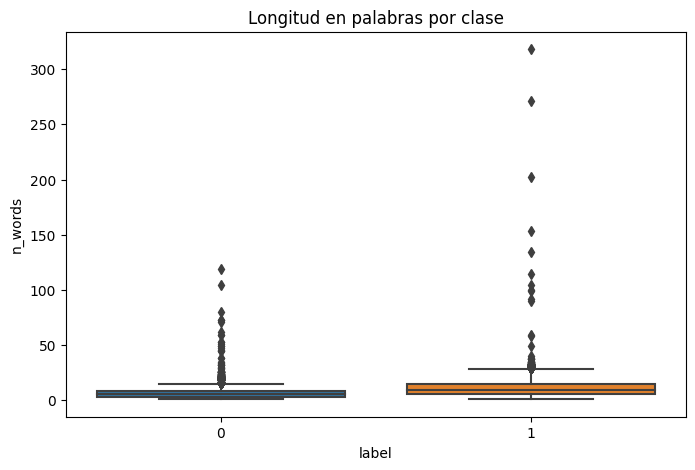

In [5]:
df['n_chars'] = df['text_preprocessed'].str.len()
df['n_words'] = df['text_preprocessed'].str.split().str.len()

print('Longitud en caracteres por clase:')
print(df.groupby('label')['n_chars'].describe())

print('\nLongitud en palabras por clase:')
print(df.groupby('label')['n_words'].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='n_words')
plt.title('Longitud en palabras por clase')
plt.show()

### Interpretación: la extensión del mensaje como señal correlacionada

La clase de bullying concentra mensajes **sistemáticamente más largos**: en promedio **10,87 palabras** (mediana 9) frente a **6,21** (mediana 6) en la clase negativa; el máximo alcanza 318 palabras frente a 119. La matriz de correlación (sección siguiente) cuantifica esta relación con un coeficiente de **≈ 0,36** entre la longitud en palabras y la clase.

Este desbalance en la extensión es una **señal espuria potencial**: un modelo léxico como TF-IDF podría aprender a usar la longitud (o la mera cantidad de términos) como proxy de la clase, en lugar del contenido del acoso. Es un sesgo del dataset que condiciona la interpretación de cualquier métrica del modelo y que se retoma en la interpretación final.


## Distribución de longitud por clase

Complementa el boxplot de longitud con un histograma superpuesto por clase. Se observa la forma de cada distribución (asimetría, colas largas) y si existe diferencia de centro entre clases. La media de cada clase se marca con una línea vertical para facilitar la comparación.


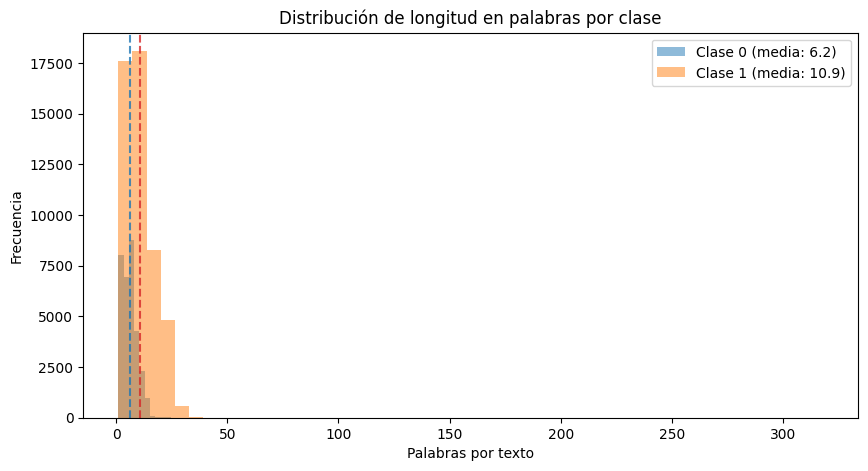

In [18]:
plt.figure(figsize=(10, 5))
for label_value in sorted(df['label'].unique()):
    subset = df.loc[df['label'] == label_value, 'n_words']
    plt.hist(subset, bins=50, alpha=0.5, label=f'Clase {label_value} (media: {subset.mean():.1f})')
    plt.axvline(subset.mean(), linestyle='--', alpha=0.8,
                color='tab:red' if label_value == 1 else 'tab:blue')

plt.xlabel('Palabras por texto')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud en palabras por clase')
plt.legend()
plt.show()

## Palabras más frecuentes por clase

Se listan los términos más frecuentes de cada clase con un conteo simple. Sirve para inspeccionar qué vocabulario caracteriza a cada clase antes de la vectorización.



Top 20 palabras — clase 0:


,word,count
0,hate,"2,957"
1,damn,"2,259"
2,like,"2,136"
3,suck,"1,640"
4,ass,"1,633"
5,think,"1,508"
6,know,"1,325"
7,good,"1,288"
8,people,"1,288"
9,fuck,"1,282"


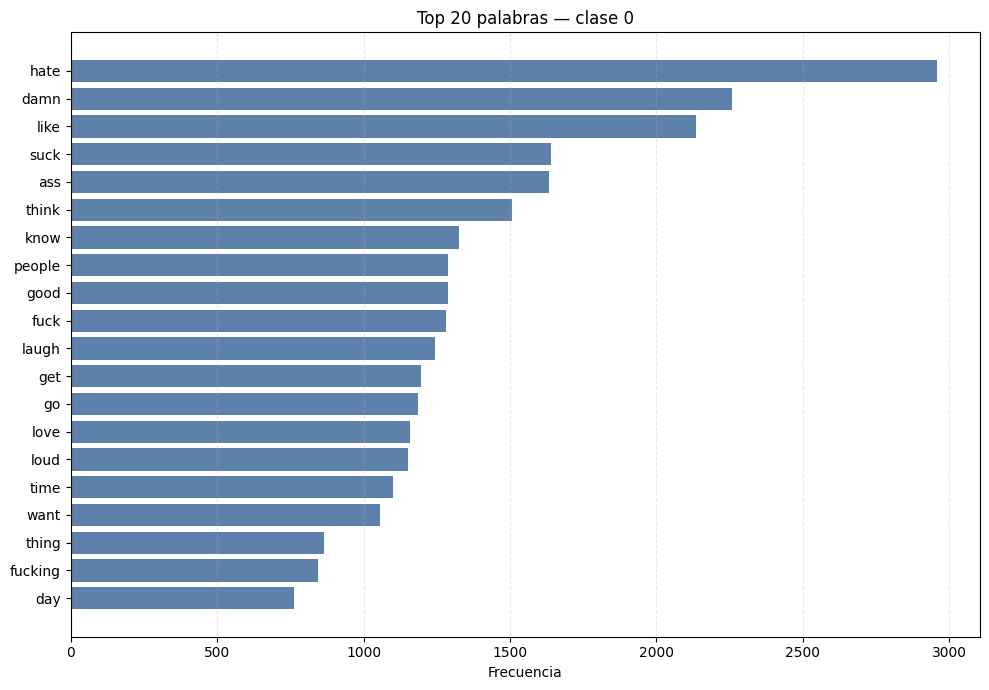


Top 20 palabras — clase 1:


,word,count
0,bully,"9,581"
1,school,"8,843"
2,fuck,"6,799"
3,like,"6,171"
4,girl,"5,722"
5,high,"5,241"
6,joke,"5,123"
7,people,"5,110"
8,nigger,"4,967"
9,dumb,"4,931"


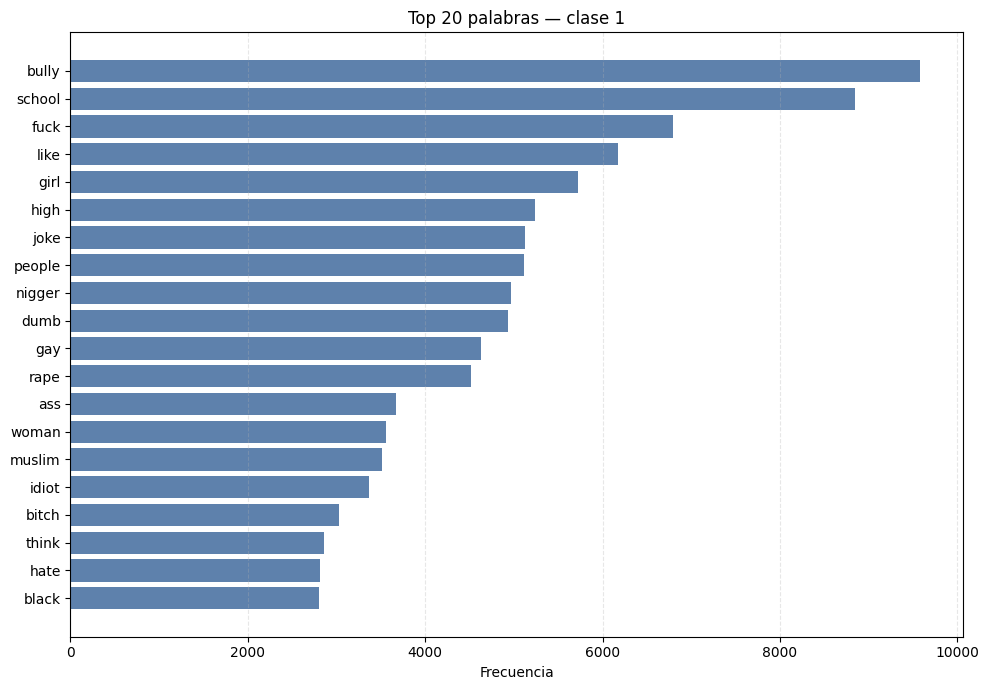

In [6]:
from collections import Counter

TOP_N = 20

for label_value in sorted(df['label'].unique()):
    word_counter = Counter()
    for document in df[df['label'] == label_value]['text_preprocessed']:
        word_counter.update(document.split())
    top_words = pd.DataFrame(word_counter.most_common(TOP_N), columns=['word', 'count'])
    print(f'\nTop {TOP_N} palabras — clase {label_value}:')

    # Tabla estilizada
    display(top_words.style.format({'count': '{:,}'}).background_gradient(
        subset=['count'], cmap='Blues'))

    # Gráfico horizontal
    top_sorted = top_words.sort_values('count')
    plt.figure(figsize=(10, 0.35 * TOP_N))
    plt.barh(top_sorted['word'], top_sorted['count'], color='#5e81ac')
    plt.xlabel('Frecuencia')
    plt.title(f'Top {TOP_N} palabras — clase {label_value}')
    plt.gca().grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Nube de palabras por clase

Como complemento visual del análisis de frecuencias anterior, se genera una nube de palabras por clase sobre el texto preprocesado. Cada nube muestra los términos dominantes de su clase —cyberbullying (1) frente a no cyberbullying (0)— y permite comparar visualmente el vocabulario típico de cada grupo.

`collocations=False` evita agrupar bigramas repetidos, de modo que la nube refleje la frecuencia de términos individuales.


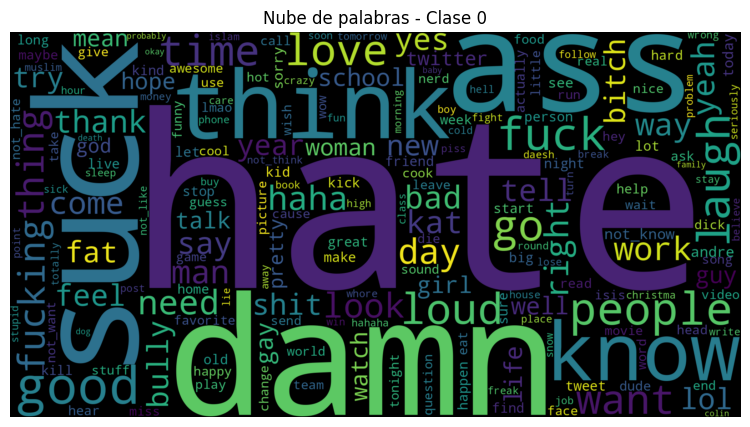

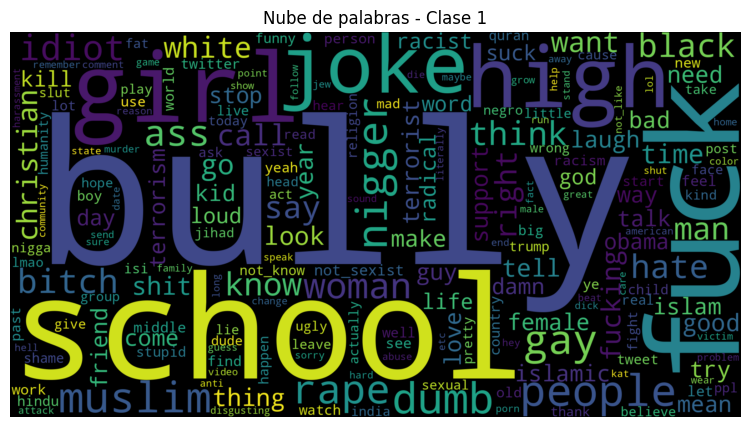

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label in df['label'].unique():
    texts = ' '.join(df.loc[df['label'] == label, 'text_preprocessed'])
    wc = WordCloud(collocations=False, width=2048, height=1080).generate(texts)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras - Clase {label}')
    plt.show()

## Correlación entre características numéricas derivadas y la clase

Sobre el texto preprocesado se derivan cuatro variables numéricas por mensaje: `n_chars` (caracteres), `n_words` (palabras), `n_unique_words` (tokens distintos) y `lexical_diversity` (riqueza léxica = tokens únicos / total de tokens, con protección ante divisiones por cero). Se calcula la matriz de correlación de Pearson entre estas variables y `label` para identificar qué características se asocian más con la clase de cyberbullying. La riqueza léxica se incluye porque la longitud absoluta y la diversidad capturan información distinta: un texto puede ser largo pero repetitivo, o corto pero léxicamente rico.


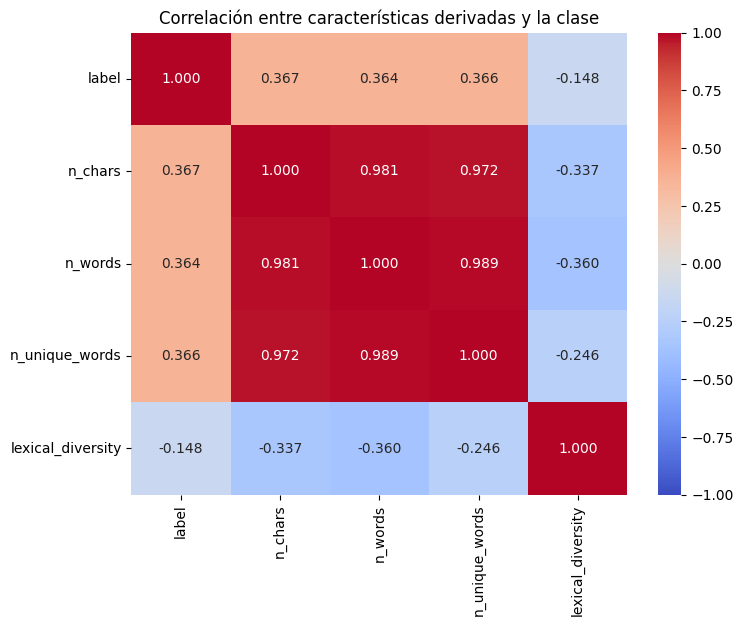

In [8]:
eda_corr = df[['label', 'text_preprocessed']].copy()
eda_corr['n_chars'] = eda_corr['text_preprocessed'].str.len()
eda_corr['n_words'] = eda_corr['text_preprocessed'].str.split().str.len()
eda_corr['n_unique_words'] = eda_corr['text_preprocessed'].str.split().apply(
    lambda tokens: len(set(tokens))
)
eda_corr['lexical_diversity'] = eda_corr.apply(
    lambda row: row['n_unique_words'] / row['n_words'] if row['n_words'] > 0 else 0.0,
    axis=1,
)

corr_matrix = eda_corr[['label', 'n_chars', 'n_words', 'n_unique_words', 'lexical_diversity']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre características derivadas y la clase')
plt.show()

### Interpretación: correlación de características derivadas con la clase

La matriz confirma cuantitativamente el patrón de extensión: las tres medidas de longitud correlacionan positivamente con la clase (caracteres **0,367**, palabras **0,364**, tokens únicos **0,366**), mientras que la riqueza léxica (tokens únicos / total de tokens) correlaciona **negativa y débilmente** (**-0,148**).

La lectura es doble. Por un lado, la extensión es la característica numérica más asociada a la clase, lo que refuerza lo señalado antes sobre el riesgo de que el modelo explote esa señal. Por otro lado, la riqueza léxica no discrimina por sí sola: la clase no se explica por tener un vocabulario más o menos diverso, sino por su contenido.


## Vocabulario distintivo por clase

Se compara el vocabulario (conjunto de tokens) de cada clase y se calcula su solapamiento. Además se identifican los términos más característicos de cada clase con el **log-odds** (logaritmo de la razón de posibilidades): para cada token, el logaritmo natural del cociente entre su frecuencia relativa en la clase 1 y su frecuencia relativa en la clase 0.

### Definición y fórmulas

Dado un término $w$, se define la frecuencia relativa de $w$ en cada clase con suavizado aditivo (evita la división por cero y $\log(0)$ cuando el término aparece en una sola clase):

$$ p_c = \frac{\mathrm{freq}_c(w) + \alpha}{\mathrm{total}_c + \alpha} $$

donde $\mathrm{freq}_c(w)$ es el número de apariciones de $w$ en la clase $c$, $\mathrm{total}_c$ el total de términos de esa clase y $\alpha = 0,5$ el suavizado. Con ambas proporciones se define el **log-odds** del término:

$$ \mathrm{log\text{-}odds}(w) = \ln\!\left( \frac{p_1}{p_0} \right) $$

### Interpretación

- $\mathrm{log\text{-}odds}(w) > 0$: el término es **más frecuente en la clase 1** (cyberbullying). A mayor valor, más característico de esa clase.
- $\mathrm{log\text{-}odds}(w) < 0$: el término es **más frecuente en la clase 0** (no cyberbullying).
- $\mathrm{log\text{-}odds}(w) \approx 0$: la palabra aparece de forma similar en ambas clases y no discrimina.

El logaritmo hace la medida **simétrica**: una razón de posibilidades de 2 (2× en clase 1) y de 0,5 (2× en clase 0) dan valores opuestos ($\ln 2$ y $-\ln 2$), de modo que la escala es interpretable alrededor de cero.

> **Nota**: este es un análisis **descriptivo**, no inferencial.


In [9]:
def token_counter(documents):
    counter = Counter()
    for document in documents:
        counter.update(document.split())
    return counter

counter_0 = token_counter(df.loc[df['label'] == 0, 'text_preprocessed'])
counter_1 = token_counter(df.loc[df['label'] == 1, 'text_preprocessed'])

vocab_0 = set(counter_0)
vocab_1 = set(counter_1)

print(f'Tamaño del vocabulario - clase 0: {len(vocab_0)}')
print(f'Tamaño del vocabulario - clase 1: {len(vocab_1)}')
print(f'Tokens compartidos entre clases: {len(vocab_0 & vocab_1)}')
print(f'Índice de Jaccard: {len(vocab_0 & vocab_1) / len(vocab_0 | vocab_1):.3f}')

Tamaño del vocabulario - clase 0: 18983
Tamaño del vocabulario - clase 1: 32455
Tokens compartidos entre clases: 12725
Índice de Jaccard: 0.329


### Interpretación: vocabulario compartido entre clases

El vocabulario de ambas clases se solapa de forma considerable: **12 725 tokens compartidos** sobre un total de 38 713, con un índice de Jaccard de **0,329**. Es decir, apenas un tercio del vocabulario total es exclusivo de una clase.

La implicación metodológica es directa: la **presencia de un término no discrimina por sí sola**. En una representación TF-IDF, donde cada documento se resume por la frecuencia y rareza de sus palabras, las mismas palabras aparecen en ambos lados de la frontera. Esto explica por qué la clasificación basada exclusivamente en vocabulario tiene un techo estructural, y anticipa la necesidad de señales contextuales.


In [10]:
import numpy as np

ALPHA = 0.5
total_0 = sum(counter_0.values())
total_1 = sum(counter_1.values())

log_odds = {}
for token in vocab_0 | vocab_1:
    p0 = (counter_0[token] + ALPHA) / (total_0 + ALPHA)
    p1 = (counter_1[token] + ALPHA) / (total_1 + ALPHA)
    log_odds[token] = np.log(p1 / p0)

top_clase1 = pd.DataFrame(
    [(token, counter_0[token], counter_1[token], round(log_odds[token], 3))
     for token in sorted(log_odds, key=log_odds.get, reverse=True)[:15]],
    columns=['token', 'frec_clase_0', 'frec_clase_1', 'log_odds'],
)
top_clase0 = pd.DataFrame(
    [(token, counter_0[token], counter_1[token], round(log_odds[token], 3))
     for token in sorted(log_odds, key=log_odds.get)[:15]],
    columns=['token', 'frec_clase_0', 'frec_clase_1', 'log_odds'],
)

print('Top 15 tokens característicos de la clase 1 (cyberbullying):')
display(top_clase1.style.format({'frec_clase_0': '{:,}', 'frec_clase_1': '{:,}', 'log_odds': '{:.3f}'})
                .background_gradient(subset=['log_odds'], cmap='coolwarm'))
print('\nTop 15 tokens característicos de la clase 0 (no cyberbullying):')
display(top_clase0.style.format({'frec_clase_0': '{:,}', 'frec_clase_1': '{:,}', 'log_odds': '{:.3f}'})
                .background_gradient(subset=['log_odds'], cmap='coolwarm'))

Top 15 tokens característicos de la clase 1 (cyberbullying):


,token,frec_clase_0,frec_clase_1,log_odds
0,nigger,0,"4,967",8.198
1,hindu,0,404,5.690
2,feminazi,0,333,5.497
3,colored,0,278,5.317
4,negro,1,557,4.913
5,blm,0,134,4.589
6,congress,0,96,4.257
7,pakistani,0,95,4.247
8,biden,0,91,4.204
9,negros,0,89,4.182



Top 15 tokens característicos de la clase 0 (no cyberbullying):


,token,frec_clase_0,frec_clase_1,log_odds
0,bhut,38,0,-5.349
1,definantly,27,0,-5.013
2,cheyenne,27,0,-5.013
3,blackberry,24,0,-4.897
4,shaz,21,0,-4.767
5,jac,19,0,-4.669
6,liver,19,0,-4.669
7,ypj,18,0,-4.616
8,beatdown,16,0,-4.502
9,pesh,16,0,-4.502


In [11]:
# Concentración de términos de identidad en la clase de bullying.
# Complementa el análisis de log-odds: cuánto se asocia la mención de un
# colectivo vulnerable con la etiqueta de bullying en este dataset.
identity_terms = ['muslim', 'gay', 'girl', 'woman', 'lesbian', 'trans', 'jew', 'immigrant']

identity_rows = []
for term in identity_terms:
    mask = df['text_preprocessed'].str.contains(r'\b' + term + r'\b', regex=True)
    n_total = mask.sum()
    if n_total == 0:
        continue
    n_bullying = (df.loc[mask, 'label'] == 1).sum()
    identity_rows.append({
        'term': term,
        'textos_con_termino': n_total,
        'textos_bullying': n_bullying,
        'pct_bullying': round(n_bullying / n_total * 100, 1),
    })

identity_summary = pd.DataFrame(identity_rows).sort_values('pct_bullying', ascending=False)
identity_summary

,term,textos_con_termino,textos_bullying,pct_bullying
4,lesbian,152,147,96.7
0,muslim,3181,3067,96.4
7,immigrant,39,37,94.9
5,trans,122,114,93.4
2,girl,5526,5111,92.5
1,gay,4764,4320,90.7
3,woman,3582,3151,88.0
6,jew,65,51,78.5


### Interpretación: riesgo de falsos positivos en términos de identidad

El análisis anterior (top de log-odds) ya mostraba términos de identidad y ofensa racial dominando la clase 1. La tabla cuantifica el fenómeno: las menciones a colectivos vulnerables aparecen **desproporcionadamente etiquetadas como bullying** en este dataset — por ejemplo, *muslim* en el **96,4 %** de sus apariciones, *gay* en el **90,7 %**, *girl* en el **92,5 %** y *woman* en el **88,0 %**.

Esta es una propiedad del **dataset**, no del modelo: la etiqueta codifica la asociación "mencionar una identidad ≈ acoso". Un clasificador entrenado sobre estos datos puede aprender esa asociación y generar **falsos positivos** cuando un mensaje simplemente habla de una persona musulmana, gay o mujer sin contenido de acoso. Es el hallazgo más sensible del EDA y la principal limitación ética a mitigar en trabajo futuro.


## N-gramas más frecuentes por clase

Se extraen los bigramas y trigramas más frecuentes de cada clase sobre el texto preprocesado, combinando tokens consecutivos con `Counter`. Los n-gramas capturan frases recurrentes que la frecuencia de unigramas no muestra. En particular, se verifica si el marcado de negación (`not_*`) del pipeline v4 aparece entre los n-gramas principales: de aparecer, la negación modifica expresiones completas (por ejemplo, `not_funny` dentro de una frase) y su presencia como señal queda justificada.


In [12]:
for label_value in sorted(df['label'].unique()):
    bigram_counter = Counter()
    trigram_counter = Counter()
    for document in df.loc[df['label'] == label_value, 'text_preprocessed']:
        tokens = document.split()
        bigram_counter.update(zip(tokens, tokens[1:]))
        trigram_counter.update(zip(tokens, tokens[1:], tokens[2:]))

    top_bigrams = pd.DataFrame(
        [(' '.join(gram), count) for gram, count in bigram_counter.most_common(10)],
        columns=['bigrama', 'frecuencia'],
    )
    top_trigrams = pd.DataFrame(
        [(' '.join(gram), count) for gram, count in trigram_counter.most_common(10)],
        columns=['trigrama', 'frecuencia'],
    )

    print(f'Clase {label_value}:')
    print('Top 10 bigramas:')
    display(top_bigrams.style.background_gradient(subset=['frecuencia'], cmap='Greens'))
    print('\nTop 10 trigramas:')
    display(top_trigrams.style.background_gradient(subset=['frecuencia'], cmap='Greens'))
    print('\n' + '-' * 40)

Clase 0:
Top 10 bigramas:


,bigrama,frecuencia
0,laugh loud,1099
1,kat andre,373
2,kick ass,222
3,look like,151
4,feel like,121
5,instant restaurant,101
6,love hate,73
7,sound like,69
8,bad ass,68
9,feel well,63



Top 10 trigramas:


,trigrama,frecuencia
0,instant restaurant round,34
1,hope feel well,34
2,ass laugh loud,27
3,deconstruct lemon tart,24
4,round instant restaurant,22
5,suck laugh loud,22
6,laugh loud hate,21
7,feel well soon,18
8,damn laugh loud,17
9,know laugh loud,15



----------------------------------------
Clase 1:
Top 10 bigramas:


,bigrama,frecuencia
0,high school,4644
1,rape joke,2098
2,bully high,1628
3,girl bully,1537
4,school bully,1525
5,dumb ass,1437
6,ass nigger,1156
7,laugh loud,1039
8,dumb fuck,1026
9,dumb nigger,999



Top 10 trigramas:


,trigrama,frecuencia
0,bully high school,1594
1,dumb ass nigger,1037
2,girl bully high,905
3,fuck obama dumb,868
4,obama dumb ass,862
5,high school bully,659
6,girl high school,424
7,fuck dumb nigger,302
8,gay rape joke,298
9,rape joke gay,253



----------------------------------------


### Interpretación: n-gramas y hallazgo negativo sobre la negación

Dos observaciones. Primero, los n-gramas de la clase 1 combinan insultos y términos de identidad en patrones típicos del acoso (p. ej. *dumb ass nigger*, *fuck dumb nigger*, *girl bully*), mientras que los de la clase 0 son expresiones coloquiales sin carga ofensiva (*kick ass*, *bad ass*). La diferencia cualitativa entre clases existe, pero depende del **contexto de la frase**, no de palabras aisladas.

Segundo, el **marcado de negación** del pipeline (`not_*`, por ejemplo `not_good`) **no aparece** entre los bigramas/trigramas más frecuentes de ninguna clase. La negación existe en los datos (se mide en la sección siguiente), pero no es una señal dominante a nivel de frases frecuentes: los patrones repetidos del corpus son mayormente afirmativos. Esto limita la utilidad práctica del marcado de negación como señal discriminante global.


## Análisis de negación por clase

El pipeline de normalización v4 marca las negaciones anteponiendo el prefijo `not_` al lema (por ejemplo, `not_good`, `not_funny`), lo que permite que el modelo las trate como señales en lugar de ignorarlas. Este análisis mide la proporción de textos de cada clase que contienen al menos un token `not_*` y compara ambas clases, para evaluar si la negación es un rasgo diferenciador y justificar (o no) mantener el marcado como señal.


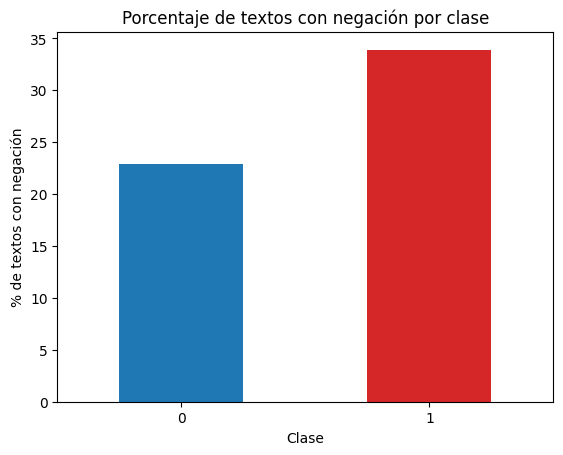

In [13]:
import re

negation_re = re.compile(r'^not_')
df['has_negation'] = df['text_preprocessed'].str.split().apply(
    lambda tokens: any(negation_re.match(token) for token in tokens)
)

negation_summary = df.groupby('label')['has_negation'].agg(con_negacion='sum', total='count')
negation_summary['porcentaje'] = (negation_summary['con_negacion'] / negation_summary['total'] * 100).round(2)
negation_summary

negation_summary['porcentaje'].plot(kind='bar', color=['tab:blue', 'tab:red'])
plt.title('Porcentaje de textos con negación por clase')
plt.xlabel('Clase')
plt.ylabel('% de textos con negación')
plt.xticks(rotation=0)
plt.show()

In [14]:
# Tabla de negación por clase (el gráfico anterior no la muestra en texto).
negation_summary[['con_negacion', 'total', 'porcentaje']]

,con_negacion,total,porcentaje
label,,,
0,7232,31598,22.89
1,16739,49376,33.90


### Interpretación: presencia de negación por clase

La negación es más frecuente en la clase de bullying: **33,90 %** de los textos de la clase 1 contienen al menos un token `not_*`, frente al **22,89 %** de la clase 0. La diferencia existe, pero no es un discriminante fuerte por sí solo: más de dos tercios de los mensajes de bullying no usan negación, y casi una cuarta parte de los mensajes no bully sí la usan. El marcado `not_*` del pipeline preserva la información de la negación (no la pierde en la normalización), pero su poder separador es limitado.


## Textos duplicados

Se detectan los textos preprocesados que se repiten. Los tweets duplicados (mensajes repetidos o retuiteados) inflan artificialmente la evaluación: si un mismo texto aparece en entrenamiento y test, el modelo lo "recuerda" y las métricas sobreestiman el rendimiento real. Por eso es relevante medir su presencia antes de definir la partición.


In [16]:
is_duplicate = df['text_preprocessed'].duplicated(keep=False)
n_duplicated_rows = is_duplicate.sum()
print(f'Filas que comparten texto con otra(s): {n_duplicated_rows} '
      f'({n_duplicated_rows / len(df) * 100:.2f}% del dataset)')

df[is_duplicate].head()

Filas que comparten texto con otra(s): 34892 (43.09% del dataset)


,text,label,text_preprocessed,n_chars,n_words,has_negation
0,"In other words #katandandre, your food was cra...",0,word food crapilicious,22,3,False
1,Why is #aussietv so white? #MKR #theblock #ImA...,0,white,5,1,False
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0,meh thank head not_concerned angry dude twitter,47,7,True
4,@RudhoeEnglish This is an ISIS account pretend...,0,isis account pretend kurdish account like isla...,51,8,False
7,@stockputout everything but mostly my priest,0,priest,6,1,False


### Interpretación: impacto de los textos duplicados

**34 892 filas (43,09 % del dataset)** comparten su texto con al menos otra fila. Los mensajes repetidos o retuiteados inflan artificialmente la evaluación: si un mismo texto cae en entrenamiento y test, el modelo puede "memorizarlo" y las métricas sobreestiman el rendimiento real.

La partición estratificada (80/20) usada en la etapa de modelado mantiene la proporción de clases pero **no elimina este riesgo**, porque la duplicación puede cruzar la frontera de la partición. Es una limitación del dataset que debe tenerse en cuenta al interpretar las métricas finales.


## Interpretación de los resultados del EDA

El análisis exploratorio revela propiedades del dataset que condicionan la estrategia de modelado y la lectura honesta de sus resultados:

- **Desbalance de clases**: la clase de bullying concentra el **60,98 %** de los mensajes frente al **39,02 %** de la clase negativa. En estas condiciones la **accuracy** es una métrica engañosa (un clasificador trivial que siempre predijera la clase mayoritaria ya acertaría ~61 %). Por eso la etapa de modelado adopta el **F1-score** como métrica principal.
- **Sesgo por longitud**: los mensajes de bullying son sistemáticamente más largos (media 10,87 vs 6,21 palabras; correlación ≈ 0,36 con la clase). El modelo podría explotar la extensión.
- **Vocabulario compartido**: el índice de Jaccard entre vocabularios es 0,329; la presencia de términos no discrimina por sí sola en una representación TF-IDF.
- **Riesgo de falsos positivos sobre identidad**: las menciones a colectivos vulnerables están etiquetadas como bullying en su gran mayoría (muslim 96,4 %, gay 90,7 %, girl 92,5 %). Un modelo puede aprender que "mencionar una identidad ≈ acoso", lo que es un riesgo ético de producto.
- **Léxico ofensivo en ambas clases**: el léxico grosero aparece en el 28,1 % de la clase negativa y en el 35,3 % de la positiva; la sola presencia de groserías no discrimina.
- **Duplicados**: el 43,09 % de las filas comparten texto, lo que puede sobreestimar las métricas si la duplicación cruza la partición.
- **Negación**: más frecuente en la clase 1 (33,90 % vs 22,89 %), pero sin poder separador fuerte; además no aparece en los n-gramas frecuentes.

En conjunto, el dataset habilita un MVP viable, pero con sesgos conocidos que condicionan la interpretación de los resultados del modelo (etapa 03) y que definen la agenda de trabajo futuro (mitigación de sesgos, fairness y modelos contextuales).
